In [1]:
from pathlib import Path

# Creates the project in the folder where this notebook is currently running
PROJECT_ROOT = Path.cwd() / "supply-chain-control-tower"

folders = [
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "notebooks",
    PROJECT_ROOT / "src",
    PROJECT_ROOT / "dashboards",
    PROJECT_ROOT / "sql",
    PROJECT_ROOT / "outputs"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder created successfully.")
print(PROJECT_ROOT)

Project folder created successfully.
/Users/nikhilkoushik/supply-chain-control-tower


In [2]:
for path in sorted(PROJECT_ROOT.rglob("*")):
    print(path)

/Users/nikhilkoushik/supply-chain-control-tower/dashboards
/Users/nikhilkoushik/supply-chain-control-tower/data
/Users/nikhilkoushik/supply-chain-control-tower/data/processed
/Users/nikhilkoushik/supply-chain-control-tower/data/raw
/Users/nikhilkoushik/supply-chain-control-tower/notebooks
/Users/nikhilkoushik/supply-chain-control-tower/outputs
/Users/nikhilkoushik/supply-chain-control-tower/sql
/Users/nikhilkoushik/supply-chain-control-tower/src


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Raw-data folder:", RAW_DIR)

Project root: /Users/nikhilkoushik/supply-chain-control-tower
Raw-data folder: /Users/nikhilkoushik/supply-chain-control-tower/data/raw


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)

# Notebook is inside supply-chain-control-tower/notebooks/
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("\nFiles found in raw folder:")

for file in RAW_DIR.iterdir():
    print("-", file.name)

Project root: /Users/nikhilkoushik/supply-chain-control-tower

Files found in raw folder:
- sales_train_evaluation.csv
- calendar.csv
- DataCoSupplyChainDataset.csv
- sell_prices.csv
- DescriptionDataCoSupplyChain.csv


In [3]:
calendar = pd.read_csv(RAW_DIR / "calendar.csv")
sell_prices = pd.read_csv(RAW_DIR / "sell_prices.csv")
sales = pd.read_csv(RAW_DIR / "sales_train_evaluation.csv")

dataco = pd.read_csv(
    RAW_DIR / "DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

print("Calendar:", calendar.shape)
print("Sell prices:", sell_prices.shape)
print("M5 sales:", sales.shape)
print("DataCo:", dataco.shape)

Calendar: (1969, 14)
Sell prices: (6841121, 4)
M5 sales: (30490, 1947)
DataCo: (180519, 53)


In [4]:
display(calendar.head())
display(sell_prices.head())
display(sales.head())
display(dataco.head())

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
def data_quality_summary(df, dataset_name):
    summary = pd.DataFrame({
        "column_name": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "missing_values": df.isnull().sum().values,
        "missing_percent": (df.isnull().mean() * 100).round(2).values,
        "unique_values": df.nunique().values
    })
    
    summary.insert(0, "dataset", dataset_name)
    return summary


quality_report = pd.concat([
    data_quality_summary(calendar, "calendar"),
    data_quality_summary(sell_prices, "sell_prices"),
    data_quality_summary(sales, "m5_sales"),
    data_quality_summary(dataco, "dataco_supply_chain")
], ignore_index=True)

quality_report.to_csv(
    OUTPUT_DIR / "data_quality_report.csv",
    index=False
)

print("Duplicate records")
print("Calendar:", calendar.duplicated().sum())
print("Sell prices:", sell_prices.duplicated().sum())
print("M5 sales:", sales.duplicated().sum())
print("DataCo:", dataco.duplicated().sum())

display(
    quality_report
    .sort_values(["dataset", "missing_percent"], ascending=[True, False])
    .head(30)
)

Duplicate records
Calendar: 0
Sell prices: 0
M5 sales: 0
DataCo: 0


,dataset,column_name,data_type,missing_values,missing_percent,unique_values
9,calendar,event_name_2,object,1964,99.75,4
10,calendar,event_type_2,object,1964,99.75,2
7,calendar,event_name_1,object,1807,91.77,30
8,calendar,event_type_1,object,1807,91.77,4
0,calendar,date,object,0,0.00,1969
1,calendar,wm_yr_wk,int64,0,0.00,282
2,calendar,weekday,object,0,0.00,7
3,calendar,wday,int64,0,0.00,7
4,calendar,month,int64,0,0.00,12
5,calendar,year,int64,0,0.00,6


In [6]:
missing_values = quality_report[quality_report["missing_values"] > 0].copy()

missing_values = missing_values.sort_values(
    ["dataset", "missing_percent"],
    ascending=[True, False]
)

display(missing_values)

,dataset,column_name,data_type,missing_values,missing_percent,unique_values
9,calendar,event_name_2,object,1964,99.75,4
10,calendar,event_type_2,object,1964,99.75,2
7,calendar,event_name_1,object,1807,91.77,30
8,calendar,event_type_1,object,1807,91.77,4
2011,dataco_supply_chain,Product Description,float64,180519,100.00,0
2008,dataco_supply_chain,Order Zipcode,float64,155679,86.24,609
1979,dataco_supply_chain,Customer Lname,object,8,0.00,1109
1984,dataco_supply_chain,Customer Zipcode,float64,3,0.00,995


In [7]:
# -----------------------------
# CLEAN M5 CALENDAR DATA
# -----------------------------
calendar_clean = calendar.copy()

calendar_clean["date"] = pd.to_datetime(
    calendar_clean["date"],
    errors="coerce"
)

event_columns = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2"
]

for column in event_columns:
    calendar_clean[column] = calendar_clean[column].fillna("No_Event")

# Create forecasting-ready date features
calendar_clean["quarter"] = calendar_clean["date"].dt.quarter
calendar_clean["week_of_year"] = calendar_clean["date"].dt.isocalendar().week.astype(int)
calendar_clean["day_of_week"] = calendar_clean["date"].dt.dayofweek
calendar_clean["is_weekend"] = calendar_clean["day_of_week"].isin([5, 6]).astype(int)

# -----------------------------
# CLEAN DATACO DATA
# -----------------------------
dataco_clean = dataco.copy()

# Remove columns with no useful analytical information
columns_to_drop = [
    "Product Description",
    "Order Zipcode",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Image"
]

dataco_clean = dataco_clean.drop(
    columns=columns_to_drop,
    errors="ignore"
)

# Rename columns into analysis-ready names
dataco_clean = dataco_clean.rename(columns={
    "Type": "payment_type",
    "Days for shipping (real)": "actual_shipping_days",
    "Days for shipment (scheduled)": "scheduled_shipping_days",
    "Benefit per order": "profit",
    "Sales per customer": "customer_sales",
    "Delivery Status": "delivery_status",
    "Late_delivery_risk": "late_delivery_flag",
    "Category Name": "product_category",
    "Department Name": "department_name",
    "Order Region": "order_region",
    "Order State": "order_state",
    "Order Status": "order_status",
    "Order Item Quantity": "order_quantity",
    "Order Item Product Price": "product_unit_price",
    "Order Item Discount": "discount_amount",
    "Order Item Discount Rate": "discount_rate",
    "Order Profit Per Order": "order_profit",
    "order date (DateOrders)": "order_date",
    "shipping date (DateOrders)": "shipping_date",
    "Shipping Mode": "shipping_mode",
    "Order Id": "order_id"
})

# Convert date fields
dataco_clean["order_date"] = pd.to_datetime(
    dataco_clean["order_date"],
    errors="coerce"
)

dataco_clean["shipping_date"] = pd.to_datetime(
    dataco_clean["shipping_date"],
    errors="coerce"
)

# Create operational metrics
dataco_clean["shipping_delay_days"] = (
    dataco_clean["actual_shipping_days"] -
    dataco_clean["scheduled_shipping_days"]
)

dataco_clean["profit_margin_percent"] = np.where(
    dataco_clean["customer_sales"] > 0,
    (dataco_clean["order_profit"] / dataco_clean["customer_sales"]) * 100,
    np.nan
)

dataco_clean["order_year"] = dataco_clean["order_date"].dt.year
dataco_clean["order_month"] = dataco_clean["order_date"].dt.month
dataco_clean["order_month_name"] = dataco_clean["order_date"].dt.month_name()

print("Clean calendar shape:", calendar_clean.shape)
print("Clean DataCo shape:", dataco_clean.shape)

display(calendar_clean.head())
display(dataco_clean.head())

Clean calendar shape: (1969, 18)
Clean DataCo shape: (180519, 50)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,quarter,week_of_year,day_of_week,is_weekend
0,2011-01-29,11101,Saturday,1,1,2011,d_1,No_Event,No_Event,No_Event,No_Event,0,0,0,1,4,5,1
1,2011-01-30,11101,Sunday,2,1,2011,d_2,No_Event,No_Event,No_Event,No_Event,0,0,0,1,4,6,1
2,2011-01-31,11101,Monday,3,1,2011,d_3,No_Event,No_Event,No_Event,No_Event,0,0,0,1,5,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,No_Event,No_Event,No_Event,No_Event,1,1,0,1,5,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,No_Event,No_Event,No_Event,No_Event,1,0,1,1,5,2,0


,payment_type,actual_shipping_days,scheduled_shipping_days,profit,customer_sales,delivery_status,late_delivery_flag,Category Id,product_category,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Id,department_name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order_date,order_id,Order Item Cardprod Id,discount_amount,discount_rate,Order Item Id,product_unit_price,Order Item Profit Ratio,order_quantity,Sales,Order Item Total,order_profit,order_region,order_state,order_status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping_date,shipping_mode,shipping_delay_days,profit_margin_percent,order_year,order_month,order_month_name
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1,29.001397,2018,1,January
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1,-80.000645,2018,1,January
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,-80.001291,2018,1,January
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1,7.499754,2018,1,January
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2,44.999164,2018,1,January


In [8]:
print("Missing values after cleaning:\n")

print("Calendar:")
display(
    calendar_clean.isnull()
    .sum()
    .loc[lambda x: x > 0]
)

print("DataCo:")
display(
    dataco_clean.isnull()
    .sum()
    .loc[lambda x: x > 0]
)

Missing values after cleaning:

Calendar:


Series([], dtype: int64)

DataCo:


Customer Zipcode    3
dtype: int64

In [10]:
# Save cleaned datasets in efficient Parquet format
calendar_clean.to_parquet(
    PROCESSED_DIR / "calendar_clean.parquet",
    index=False
)

dataco_clean.to_parquet(
    PROCESSED_DIR / "dataco_clean.parquet",
    index=False
)

# Also save CSV versions for easy viewing and GitHub use
calendar_clean.to_csv(
    PROCESSED_DIR / "calendar_clean.csv",
    index=False
)

print("Saved successfully:")
print("-", PROCESSED_DIR / "calendar_clean.parquet")
print("-", PROCESSED_DIR / "dataco_clean.parquet")

Saved successfully:
- /Users/nikhilkoushik/supply-chain-control-tower/data/processed/calendar_clean.parquet
- /Users/nikhilkoushik/supply-chain-control-tower/data/processed/dataco_clean.parquet


In [11]:
total_orders = dataco_clean["order_id"].nunique()
total_sales = dataco_clean["customer_sales"].sum()
total_profit = dataco_clean["order_profit"].sum()
late_delivery_rate = dataco_clean["late_delivery_flag"].mean() * 100
average_shipping_days = dataco_clean["actual_shipping_days"].mean()
average_shipping_delay = dataco_clean["shipping_delay_days"].mean()

print(f"Total unique orders: {total_orders:,.0f}")
print(f"Total sales: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Late-delivery rate: {late_delivery_rate:.2f}%")
print(f"Average actual shipping time: {average_shipping_days:.2f} days")
print(f"Average shipping delay vs scheduled: {average_shipping_delay:.2f} days")

Total unique orders: 65,752
Total sales: $33,054,402.38
Total profit: $3,966,902.97
Late-delivery rate: 54.83%
Average actual shipping time: 3.50 days
Average shipping delay vs scheduled: 0.57 days


In [12]:
category_performance = (
    dataco_clean
    .groupby("product_category", as_index=False)
    .agg(
        total_sales=("customer_sales", "sum"),
        total_profit=("order_profit", "sum"),
        total_orders=("order_id", "nunique"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

category_performance["late_delivery_rate"] = (
    category_performance["late_delivery_rate"] * 100
).round(2)

category_performance = category_performance.sort_values(
    "total_sales",
    ascending=False
)

category_performance.to_csv(
    OUTPUT_DIR / "dataco_category_performance.csv",
    index=False
)

display(category_performance.head(10))

,product_category,total_sales,total_profit,total_orders,late_delivery_rate,average_shipping_delay
18,Fishing,6.226935e+06,756220.767190,15164,54.93,0.555152
12,Cleats,3.982857e+06,494636.919791,20386,54.97,0.576962
9,Camping & Hiking,3.700784e+06,427455.568106,12299,54.53,0.551388
10,Cardio Equipment,3.320251e+06,383011.098485,11355,54.50,0.554337
47,Women's Apparel,2.828708e+06,350421.029567,17869,54.56,0.559544
46,Water Sports,2.798044e+06,325146.960038,13758,54.81,0.567310
34,Men's Footwear,2.598494e+06,311902.820214,18783,54.49,0.564191
30,Indoor/Outdoor Games,2.596454e+06,318451.430554,16623,54.75,0.564722
38,Shop By Sport,1.177186e+06,129813.960315,10136,55.15,0.575291
13,Computers,5.953950e+05,69656.810171,442,50.68,0.454751


In [13]:
# Late-delivery performance by shipping mode
shipping_mode_performance = (
    dataco_clean
    .groupby("shipping_mode", as_index=False)
    .agg(
        total_sales=("customer_sales", "sum"),
        total_orders=("order_id", "nunique"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        average_actual_shipping_days=("actual_shipping_days", "mean"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

shipping_mode_performance["late_delivery_rate"] = (
    shipping_mode_performance["late_delivery_rate"] * 100
).round(2)

shipping_mode_performance = shipping_mode_performance.sort_values(
    "late_delivery_rate",
    ascending=False
)

display(shipping_mode_performance)

,shipping_mode,total_sales,total_orders,late_delivery_rate,average_actual_shipping_days,average_shipping_delay
0,First Class,5.100451e+06,10079,95.32,2.000000,1.000000
2,Second Class,6.416529e+06,12778,76.63,3.990828,1.990828
1,Same Day,1.745202e+06,3571,45.74,0.478279,0.478279
3,Standard Class,1.979222e+07,39324,38.07,3.995907,-0.004093


In [14]:
# Late-delivery performance by order region
region_performance = (
    dataco_clean
    .groupby("order_region", as_index=False)
    .agg(
        total_sales=("customer_sales", "sum"),
        total_orders=("order_id", "nunique"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

region_performance["late_delivery_rate"] = (
    region_performance["late_delivery_rate"] * 100
).round(2)

region_performance = region_performance.sort_values(
    "late_delivery_rate",
    ascending=False
)

display(region_performance.head(10))

,order_region,total_sales,total_orders,late_delivery_rate,average_shipping_delay
2,Central Africa,2.929126e+05,556,57.96,0.639833
13,South Asia,1.397365e+06,3335,56.27,0.597465
5,East Africa,3.380543e+05,613,55.94,0.570734
22,Western Europe,5.296003e+06,10010,55.85,0.597403
14,South of USA,7.069043e+05,1345,55.77,0.579975
6,East of USA,1.231955e+06,2323,55.66,0.584816
8,Eastern Europe,6.963072e+05,1292,55.66,0.579847
15,Southeast Asia,1.738553e+06,4356,55.53,0.558235
4,Central Asia,9.795369e+04,184,55.33,0.645570
20,West Asia,1.056081e+06,2022,55.28,0.569479


In [15]:
# Late-delivery performance by order status
order_status_performance = (
    dataco_clean
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_sales=("customer_sales", "sum"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

order_status_performance["late_delivery_rate"] = (
    order_status_performance["late_delivery_rate"] * 100
).round(2)

order_status_performance = order_status_performance.sort_values(
    "late_delivery_rate",
    ascending=False
)

display(order_status_performance)

,order_status,total_orders,total_sales,late_delivery_rate,average_shipping_delay
5,PENDING,7321,3.704456e+06,57.90,0.572650
6,PENDING_PAYMENT,14382,7.286276e+06,57.55,0.588472
2,COMPLETE,21716,1.085927e+07,57.49,0.562320
4,PAYMENT_REVIEW,704,3.455762e+05,57.16,0.598521
7,PROCESSING,7901,4.051381e+06,57.09,0.555337
1,CLOSED,7249,3.617467e+06,56.63,0.547716
3,ON_HOLD,3624,1.780238e+06,55.59,0.528560
0,CANCELED,1367,6.682450e+05,0.00,0.559047
8,SUSPECTED_FRAUD,1488,7.414923e+05,0.00,0.585180


In [16]:
shipping_mode_performance.to_csv(
    OUTPUT_DIR / "shipping_mode_performance.csv",
    index=False
)

region_performance.to_csv(
    OUTPUT_DIR / "region_performance.csv",
    index=False
)

order_status_performance.to_csv(
    OUTPUT_DIR / "order_status_performance.csv",
    index=False
)

/var/folders/wc/lx3pfn8x11z402lzlm429n0w0000gn/T/ipykernel_90819/3747508889.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


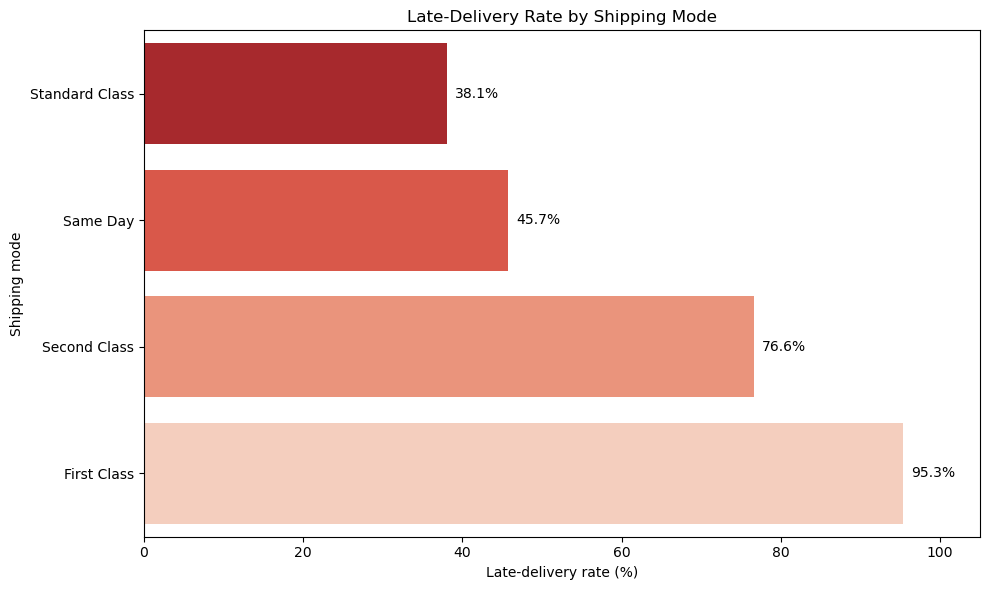

In [17]:
plt.figure(figsize=(10, 6))

shipping_plot = shipping_mode_performance.sort_values(
    "late_delivery_rate",
    ascending=True
)

sns.barplot(
    data=shipping_plot,
    x="late_delivery_rate",
    y="shipping_mode",
    palette="Reds_r"
)

plt.title("Late-Delivery Rate by Shipping Mode")
plt.xlabel("Late-delivery rate (%)")
plt.ylabel("Shipping mode")

for index, value in enumerate(shipping_plot["late_delivery_rate"]):
    plt.text(value + 1, index, f"{value:.1f}%", va="center")

plt.xlim(0, 105)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "late_delivery_rate_by_shipping_mode.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
shipping_mode_impact = (
    dataco_clean
    .groupby("shipping_mode", as_index=False)
    .agg(
        shipment_records=("order_id", "count"),
        late_shipment_records=("late_delivery_flag", "sum"),
        total_sales=("customer_sales", "sum"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

shipping_mode_impact["late_delivery_rate"] = (
    shipping_mode_impact["late_shipment_records"] /
    shipping_mode_impact["shipment_records"] * 100
).round(2)

shipping_mode_impact = shipping_mode_impact.sort_values(
    "late_shipment_records",
    ascending=False
)

display(shipping_mode_impact)

shipping_mode_impact.to_csv(
    OUTPUT_DIR / "shipping_mode_late_delivery_impact.csv",
    index=False
)

,shipping_mode,shipment_records,late_shipment_records,total_sales,average_shipping_delay,late_delivery_rate
3,Standard Class,107752,41023,1.979222e+07,-0.004093,38.07
2,Second Class,35216,26987,6.416529e+06,1.990828,76.63
0,First Class,27814,26513,5.100451e+06,1.000000,95.32
1,Same Day,9737,4454,1.745202e+06,0.478279,45.74


## Root-Cause Finding: Shipping-Mode Performance

Late-delivery risk is driven primarily by shipping-mode performance. First Class shipments have a 95.32% late-delivery rate, while Second Class shipments have a 76.63% rate. Both services consistently exceed their scheduled delivery time by approximately one and two days, respectively.

Standard Class performs best, with a 38.07% late-delivery rate and average shipping time aligned with the scheduled commitment. The recommended operational action is to recalibrate First and Second Class delivery promises and investigate carrier capacity, warehouse dispatch delays, and route-level constraints.

In [19]:
region_impact = (
    dataco_clean
    .groupby("order_region", as_index=False)
    .agg(
        shipment_records=("order_id", "count"),
        late_shipment_records=("late_delivery_flag", "sum"),
        total_sales=("customer_sales", "sum"),
        total_profit=("order_profit", "sum"),
        average_shipping_delay=("shipping_delay_days", "mean")
    )
)

region_impact["late_delivery_rate"] = (
    region_impact["late_shipment_records"] /
    region_impact["shipment_records"] * 100
).round(2)

region_impact = region_impact.sort_values(
    "late_shipment_records",
    ascending=False
)

display(region_impact.head(10))

region_impact.to_csv(
    OUTPUT_DIR / "regional_late_delivery_impact.csv",
    index=False
)

,order_region,shipment_records,late_shipment_records,total_sales,total_profit,average_shipping_delay,late_delivery_rate
3,Central America,28341,15518,5.093850e+06,616341.570651,0.561942,54.75
22,Western Europe,27109,15140,5.296003e+06,625446.080548,0.597403,55.85
12,South America,14935,8111,2.660244e+06,335154.400817,0.556344,54.31
11,Oceania,10148,5482,1.809997e+06,201478.020484,0.556267,54.02
15,Southeast Asia,9539,5297,1.738553e+06,211342.819786,0.558235,55.53
10,Northern Europe,9792,5292,1.939362e+06,233450.600647,0.546875,54.04
17,Southern Europe,9431,5129,1.837526e+06,230829.229883,0.515640,54.38
1,Caribbean,8318,4415,1.481669e+06,171825.640024,0.546526,53.08
13,South Asia,7731,4350,1.397365e+06,165703.900124,0.597465,56.27
21,West of USA,7993,4313,1.412254e+06,164940.660455,0.557238,53.96


In [20]:
region_impact["priority_score"] = (
    region_impact["late_shipment_records"] *
    region_impact["late_delivery_rate"]
)

priority_regions = region_impact.sort_values(
    "priority_score",
    ascending=False
).head(10)

display(
    priority_regions[
        [
            "order_region",
            "shipment_records",
            "late_shipment_records",
            "late_delivery_rate",
            "total_sales",
            "average_shipping_delay",
            "priority_score"
        ]
    ]
)

,order_region,shipment_records,late_shipment_records,late_delivery_rate,total_sales,average_shipping_delay,priority_score
3,Central America,28341,15518,54.75,5.093850e+06,0.561942,849610.50
22,Western Europe,27109,15140,55.85,5.296003e+06,0.597403,845569.00
12,South America,14935,8111,54.31,2.660244e+06,0.556344,440508.41
11,Oceania,10148,5482,54.02,1.809997e+06,0.556267,296137.64
15,Southeast Asia,9539,5297,55.53,1.738553e+06,0.558235,294142.41
10,Northern Europe,9792,5292,54.04,1.939362e+06,0.546875,285979.68
17,Southern Europe,9431,5129,54.38,1.837526e+06,0.515640,278915.02
13,South Asia,7731,4350,56.27,1.397365e+06,0.597465,244774.50
1,Caribbean,8318,4415,53.08,1.481669e+06,0.546526,234348.20
21,West of USA,7993,4313,53.96,1.412254e+06,0.557238,232729.48


/var/folders/wc/lx3pfn8x11z402lzlm429n0w0000gn/T/ipykernel_90819/3948028793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


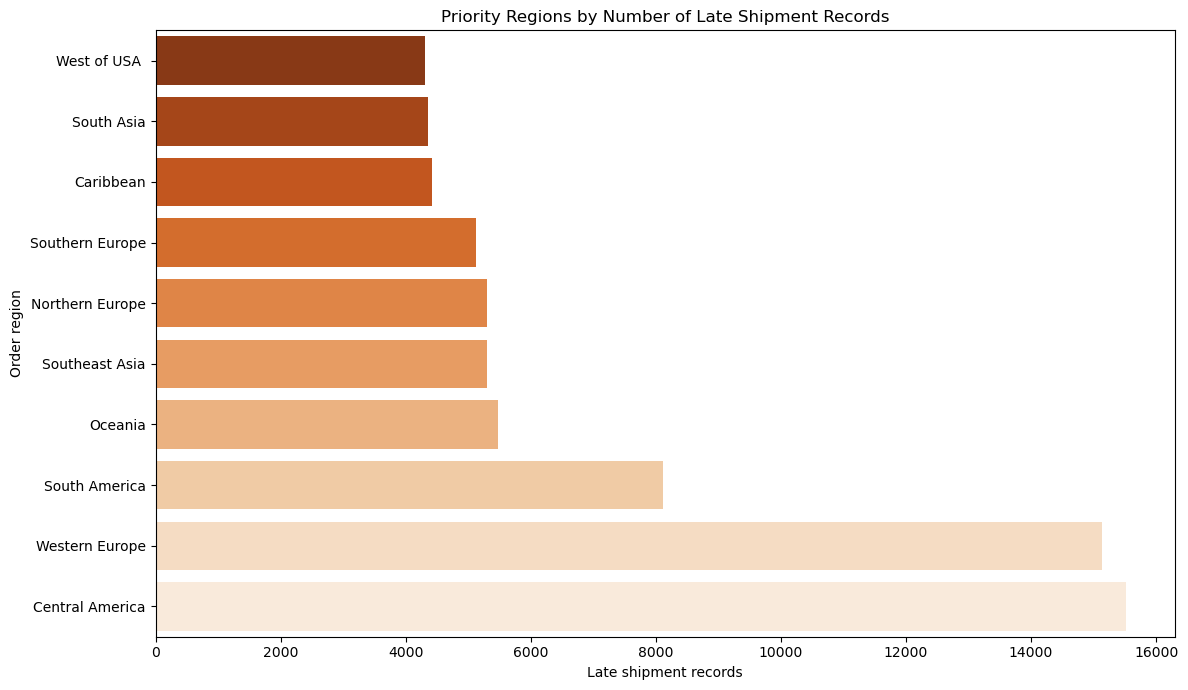

In [21]:
chart_data = priority_regions.sort_values(
    "late_shipment_records",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=chart_data,
    x="late_shipment_records",
    y="order_region",
    palette="Oranges_r"
)

plt.title("Priority Regions by Number of Late Shipment Records")
plt.xlabel("Late shipment records")
plt.ylabel("Order region")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "priority_regions_late_shipments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Keep one store for the initial forecasting pipeline
sales_ca1 = sales[sales["store_id"] == "CA_1"].copy()

print("CA_1 SKU series:", sales_ca1.shape[0])
print("CA_1 columns:", sales_ca1.shape[1])

sales_ca1.head()

CA_1 SKU series: 3049
CA_1 columns: 1947


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0


In [23]:
id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

day_columns = [
    column for column in sales_ca1.columns
    if column.startswith("d_")
]

m5_ca1_daily = sales_ca1.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="units_sold"
)

m5_ca1_daily["units_sold"] = m5_ca1_daily["units_sold"].astype("int16")

print("CA_1 daily demand dataset:", m5_ca1_daily.shape)

display(m5_ca1_daily.head())

CA_1 daily demand dataset: (5918109, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [26]:
# Keep only fields needed for demand, price, and inventory analysis
calendar_features = calendar_clean[
    [
        "d", "date", "wm_yr_wk", "year", "month",
        "week_of_year", "day_of_week", "is_weekend",
        "event_name_1", "event_type_1", "snap_CA"
    ]
].copy()

# Join daily demand with calendar attributes
m5_enriched = m5_ca1_daily.merge(
    calendar_features,
    on="d",
    how="left",
    validate="many_to_one"
)

# Join store-SKU-week prices
m5_enriched = m5_enriched.merge(
    sell_prices[
        ["store_id", "item_id", "wm_yr_wk", "sell_price"]
    ],
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
    validate="many_to_one"
)

# Revenue is zero where a SKU has no recorded price
m5_enriched["sell_price"] = m5_enriched["sell_price"].fillna(0)
m5_enriched["revenue"] = (
    m5_enriched["units_sold"] * m5_enriched["sell_price"]
)

# Remove ID because item/store/date already identify each record
m5_enriched = m5_enriched.drop(columns="id")

print("Enriched M5 dataset shape:", m5_enriched.shape)
print("Missing dates:", m5_enriched["date"].isna().sum())
print("Missing prices:", m5_enriched["sell_price"].isna().sum())

display(m5_enriched.head())

Enriched M5 dataset shape: (5918109, 19)
Missing dates: 0
Missing prices: 0


,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,year,month,week_of_year,day_of_week,is_weekend,event_name_1,event_type_1,snap_CA,sell_price,revenue
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,2011,1,4,5,1,No_Event,No_Event,0,0.0,0.0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,2011,1,4,5,1,No_Event,No_Event,0,0.0,0.0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,2011,1,4,5,1,No_Event,No_Event,0,0.0,0.0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,2011,1,4,5,1,No_Event,No_Event,0,0.0,0.0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,2011,1,4,5,1,No_Event,No_Event,0,0.0,0.0


In [27]:
m5_enriched.to_parquet(
    PROCESSED_DIR / "m5_ca1_daily_enriched.parquet",
    index=False
)

print("Saved:", PROCESSED_DIR / "m5_ca1_daily_enriched.parquet")

Saved: /Users/nikhilkoushik/supply-chain-control-tower/data/processed/m5_ca1_daily_enriched.parquet


In [28]:
m5_summary = (
    m5_enriched
    .groupby("cat_id", as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        unique_skus=("item_id", "nunique"),
        average_daily_units=("units_sold", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

display(m5_summary)

m5_summary.to_csv(
    OUTPUT_DIR / "m5_category_demand_summary.csv",
    index=False
)

,cat_id,total_units_sold,total_revenue,unique_skus,average_daily_units
0,FOODS,5471661,13628360.34,1437,1.961719
2,HOUSEHOLD,1468504,6100507.55,1047,0.722608
1,HOBBIES,892083,3225415.88,565,0.813451


In [29]:
m5_summary = (
    m5_enriched
    .groupby("cat_id", as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        unique_skus=("item_id", "nunique"),
        average_daily_units=("units_sold", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

m5_summary["total_revenue"] = m5_summary["total_revenue"].round(2)
m5_summary["average_daily_units"] = m5_summary["average_daily_units"].round(2)

display(m5_summary)

m5_summary.to_csv(
    OUTPUT_DIR / "m5_category_demand_summary.csv",
    index=False
)

,cat_id,total_units_sold,total_revenue,unique_skus,average_daily_units
0,FOODS,5471661,13628360.34,1437,1.96
2,HOUSEHOLD,1468504,6100507.55,1047,0.72
1,HOBBIES,892083,3225415.88,565,0.81


In [30]:
sku_volatility = (
    m5_enriched
    .groupby(["item_id", "dept_id", "cat_id"], as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        demand_standard_deviation=("units_sold", "std"),
        days_with_demand=("units_sold", lambda x: (x > 0).sum())
    )
)

sku_volatility["demand_cv"] = (
    sku_volatility["demand_standard_deviation"] /
    sku_volatility["average_daily_demand"]
)

sku_volatility["demand_cv"] = (
    sku_volatility["demand_cv"]
    .replace([np.inf, -np.inf], np.nan)
)

sku_volatility = sku_volatility.sort_values(
    "demand_cv",
    ascending=False
)

display(sku_volatility.head(10))

,item_id,dept_id,cat_id,total_units_sold,average_daily_demand,demand_standard_deviation,days_with_demand,demand_cv
1462,HOBBIES_1_026,HOBBIES_1,HOBBIES,26,0.013395,0.127731,24,9.535644
2372,HOUSEHOLD_1_378,HOUSEHOLD_1,HOUSEHOLD,23,0.011850,0.112899,22,9.527667
2130,HOUSEHOLD_1_133,HOUSEHOLD_1,HOUSEHOLD,1268,0.653272,5.685651,518,8.703350
962,FOODS_3_350,FOODS_3,FOODS,94,0.048429,0.358582,45,7.404344
2295,HOUSEHOLD_1_300,HOUSEHOLD_1,HOUSEHOLD,58,0.029882,0.200858,49,6.721801
1875,HOBBIES_2_023,HOBBIES_2,HOBBIES,81,0.041731,0.277711,59,6.654787
2777,HOUSEHOLD_2_245,HOUSEHOLD_2,HOUSEHOLD,59,0.030397,0.202060,51,6.647423
908,FOODS_3_296,FOODS_3,FOODS,70,0.036064,0.239712,51,6.646858
2762,HOUSEHOLD_2_230,HOUSEHOLD_2,HOUSEHOLD,55,0.028336,0.183665,50,6.481696
423,FOODS_2_209,FOODS_2,FOODS,92,0.047398,0.305988,59,6.455677


In [31]:
# Revenue contribution by SKU
sku_abc = (
    m5_enriched
    .groupby(["item_id", "dept_id", "cat_id"], as_index=False)
    .agg(
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        days_with_demand=("units_sold", lambda x: (x > 0).sum())
    )
    .sort_values("total_revenue", ascending=False)
)

sku_abc["revenue_share"] = (
    sku_abc["total_revenue"] / sku_abc["total_revenue"].sum()
)

sku_abc["cumulative_revenue_share"] = (
    sku_abc["revenue_share"].cumsum()
)

# ABC inventory classification
sku_abc["abc_class"] = np.select(
    [
        sku_abc["cumulative_revenue_share"] <= 0.80,
        sku_abc["cumulative_revenue_share"] <= 0.95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

display(
    sku_abc
    .groupby("abc_class", as_index=False)
    .agg(
        sku_count=("item_id", "nunique"),
        total_revenue=("total_revenue", "sum"),
        total_units_sold=("total_units_sold", "sum")
    )
)

,abc_class,sku_count,total_revenue,total_units_sold
0,A,1217,18358816.71,6055989
1,B,925,3446718.57,1278066
2,C,907,1148748.49,498193


In [32]:
# Calculate demand statistics only on days with positive sales
positive_demand = (
    m5_enriched[m5_enriched["units_sold"] > 0]
    .groupby("item_id", as_index=False)
    .agg(
        demand_days=("date", "count"),
        mean_nonzero_demand=("units_sold", "mean"),
        std_nonzero_demand=("units_sold", "std")
    )
)

total_days = m5_enriched["date"].nunique()

positive_demand["average_demand_interval"] = (
    total_days / positive_demand["demand_days"]
)

positive_demand["cv_squared"] = (
    positive_demand["std_nonzero_demand"] /
    positive_demand["mean_nonzero_demand"]
) ** 2

# Standard inventory-demand segmentation
positive_demand["demand_pattern"] = np.select(
    [
        (positive_demand["average_demand_interval"] < 1.32) &
        (positive_demand["cv_squared"] < 0.49),

        (positive_demand["average_demand_interval"] < 1.32) &
        (positive_demand["cv_squared"] >= 0.49),

        (positive_demand["average_demand_interval"] >= 1.32) &
        (positive_demand["cv_squared"] < 0.49)
    ],
    [
        "Smooth",
        "Erratic",
        "Intermittent"
    ],
    default="Lumpy"
)

inventory_segmentation = (
    sku_abc
    .merge(
        positive_demand[
            [
                "item_id",
                "demand_days",
                "average_demand_interval",
                "cv_squared",
                "demand_pattern"
            ]
        ],
        on="item_id",
        how="left"
    )
)

display(
    inventory_segmentation
    .groupby(["abc_class", "demand_pattern"], as_index=False)
    .agg(
        sku_count=("item_id", "nunique"),
        total_revenue=("total_revenue", "sum")
    )
    .sort_values(["abc_class", "total_revenue"], ascending=[True, False])
)

,abc_class,demand_pattern,sku_count,total_revenue
1,A,Intermittent,811,10537990.27
3,A,Smooth,132,4372818.31
2,A,Lumpy,233,2428353.88
0,A,Erratic,41,1019654.25
5,B,Intermittent,731,2712210.58
6,B,Lumpy,191,720446.15
7,B,Smooth,2,8750.12
4,B,Erratic,1,5311.72
8,C,Intermittent,751,939020.58
9,C,Lumpy,156,209727.91


In [33]:
inventory_segmentation.to_csv(
    OUTPUT_DIR / "m5_abc_demand_segmentation.csv",
    index=False
)

In [34]:
# Select the top 20 high-value, stable-demand SKUs for the initial forecast model
forecasting_scope = (
    inventory_segmentation[
        (inventory_segmentation["abc_class"] == "A") &
        (inventory_segmentation["demand_pattern"] == "Smooth")
    ]
    .sort_values("total_revenue", ascending=False)
    .head(20)
    .copy()
)

forecasting_skus = forecasting_scope["item_id"].tolist()

display(
    forecasting_scope[
        [
            "item_id",
            "dept_id",
            "cat_id",
            "total_units_sold",
            "total_revenue",
            "average_demand_interval",
            "cv_squared",
            "demand_pattern"
        ]
    ]
)

,item_id,dept_id,cat_id,total_units_sold,total_revenue,average_demand_interval,cv_squared,demand_pattern
1,FOODS_3_090,FOODS_3,FOODS,128855,175257.74,1.318614,0.327244,Smooth
2,FOODS_3_586,FOODS_3,FOODS,88846,141530.58,1.003619,0.123369,Smooth
3,FOODS_3_202,FOODS_3,FOODS,31825,136388.80,1.121965,0.233066,Smooth
4,FOODS_2_197,FOODS_2,FOODS,41312,133059.54,1.089226,0.244339,Smooth
5,FOODS_3_587,FOODS_3,FOODS,52356,132607.48,1.306191,0.244306,Smooth
6,FOODS_2_244,FOODS_2,FOODS,20210,117365.84,1.079533,0.332683,Smooth
7,FOODS_3_252,FOODS_3,FOODS,76055,115746.30,1.003101,0.223429,Smooth
8,FOODS_2_019,FOODS_2,FOODS,35716,114867.28,1.091062,0.240494,Smooth
11,HOUSEHOLD_1_535,HOUSEHOLD_1,HOUSEHOLD,12884,89801.48,1.172810,0.377049,Smooth
12,FOODS_2_276,FOODS_2,FOODS,26772,85153.96,1.108509,0.374136,Smooth


In [35]:
forecast_data = (
    m5_enriched[
        m5_enriched["item_id"].isin(forecasting_skus)
    ]
    .sort_values(["item_id", "date"])
    .copy()
)

# Keep the forecasting-relevant columns
forecast_data = forecast_data[
    [
        "date",
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "units_sold",
        "sell_price",
        "revenue",
        "month",
        "week_of_year",
        "day_of_week",
        "is_weekend",
        "event_name_1",
        "snap_CA"
    ]
]

print("Forecasting dataset shape:", forecast_data.shape)
print("Selected SKUs:", forecast_data["item_id"].nunique())
print("Date range:", forecast_data["date"].min(), "to", forecast_data["date"].max())

display(forecast_data.head())

Forecasting dataset shape: (38820, 14)
Selected SKUs: 20
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00


,date,item_id,dept_id,cat_id,store_id,units_sold,sell_price,revenue,month,week_of_year,day_of_week,is_weekend,event_name_1,snap_CA
1846,2011-01-29,FOODS_2_019,FOODS_2,FOODS,CA_1,15,2.98,44.70,1,4,5,1,No_Event,0
4895,2011-01-30,FOODS_2_019,FOODS_2,FOODS,CA_1,27,2.98,80.46,1,4,6,1,No_Event,0
7944,2011-01-31,FOODS_2_019,FOODS_2,FOODS,CA_1,18,2.98,53.64,1,5,0,0,No_Event,0
10993,2011-02-01,FOODS_2_019,FOODS_2,FOODS,CA_1,29,2.98,86.42,2,5,1,0,No_Event,1
14042,2011-02-02,FOODS_2_019,FOODS_2,FOODS,CA_1,23,2.98,68.54,2,5,2,0,No_Event,1


In [36]:
forecast_data.to_parquet(
    PROCESSED_DIR / "m5_ca1_forecasting_scope.parquet",
    index=False
)

In [37]:
forecast_data.groupby("item_id", as_index=False).agg(
    total_units_sold=("units_sold", "sum"),
    average_daily_demand=("units_sold", "mean"),
    total_revenue=("revenue", "sum")
).sort_values("total_revenue", ascending=False)

,item_id,total_units_sold,average_daily_demand,total_revenue
6,FOODS_3_090,128855,66.385884,175257.74
14,FOODS_3_586,88846,45.773313,141530.58
8,FOODS_3_202,31825,16.396188,136388.80
1,FOODS_2_197,41312,21.283874,133059.54
15,FOODS_3_587,52356,26.973725,132607.48
2,FOODS_2_244,20210,10.412159,117365.84
9,FOODS_3_252,76055,39.183411,115746.30
0,FOODS_2_019,35716,18.400824,114867.28
19,HOUSEHOLD_1_535,12884,6.637816,89801.48
3,FOODS_2_276,26772,13.792890,85153.96


In [38]:
# Work in chronological SKU order
model_data = forecast_data.sort_values(["item_id", "date"]).copy()

# Demand lags
for lag in [1, 7, 14, 28]:
    model_data[f"lag_{lag}"] = (
        model_data
        .groupby("item_id")["units_sold"]
        .shift(lag)
    )

# Rolling demand averages.
# shift(1) ensures the current day's demand is never used to predict itself.
for window in [7, 14, 28]:
    model_data[f"rolling_mean_{window}"] = (
        model_data
        .groupby("item_id")["units_sold"]
        .transform(lambda x: x.shift(1).rolling(window=window).mean())
    )

# Recent demand variability: useful for inventory-safety-stock decisions
model_data["rolling_std_28"] = (
    model_data
    .groupby("item_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=28).std())
)

# Encode the event field for the ML model
model_data["event_name_1"] = (
    model_data["event_name_1"]
    .fillna("No_Event")
    .astype("category")
)

model_data["event_code"] = model_data["event_name_1"].cat.codes

# The first 28 days per SKU do not have enough demand history
model_data = model_data.dropna().reset_index(drop=True)

print("Model-ready dataset shape:", model_data.shape)
print("Earliest model date:", model_data["date"].min())
print("Latest model date:", model_data["date"].max())

display(
    model_data[
        [
            "date", "item_id", "units_sold",
            "lag_1", "lag_7", "lag_28",
            "rolling_mean_7", "rolling_mean_28",
            "rolling_std_28", "sell_price"
        ]
    ].head()
)

Model-ready dataset shape: (38260, 23)
Earliest model date: 2011-02-26 00:00:00
Latest model date: 2016-05-22 00:00:00


,date,item_id,units_sold,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_28,sell_price
0,2011-02-26,FOODS_2_019,0,8.0,26.0,15.0,10.142857,15.357143,11.662584,2.98
1,2011-02-27,FOODS_2_019,19,0.0,25.0,27.0,6.428571,14.821429,12.018669,2.98
2,2011-02-28,FOODS_2_019,6,19.0,5.0,18.0,5.571429,14.535714,11.811740,2.98
3,2011-03-01,FOODS_2_019,8,6.0,0.0,29.0,5.714286,14.107143,11.898768,2.98
4,2011-03-02,FOODS_2_019,1,8.0,6.0,23.0,6.857143,13.357143,11.582919,2.98


In [39]:
test_start_date = model_data["date"].max() - pd.Timedelta(days=27)

train_data = model_data[
    model_data["date"] < test_start_date
].copy()

test_data = model_data[
    model_data["date"] >= test_start_date
].copy()

print("Training period:", train_data["date"].min(), "to", train_data["date"].max())
print("Test period:", test_data["date"].min(), "to", test_data["date"].max())

print("\nTraining rows:", train_data.shape[0])
print("Test rows:", test_data.shape[0])

print("\nTest days per SKU:")
display(test_data.groupby("item_id")["date"].nunique().head())

Training period: 2011-02-26 00:00:00 to 2016-04-24 00:00:00
Test period: 2016-04-25 00:00:00 to 2016-05-22 00:00:00

Training rows: 37700
Test rows: 560

Test days per SKU:


item_id
FOODS_2_019    28
FOODS_2_197    28
FOODS_2_244    28
FOODS_2_276    28
FOODS_2_347    28
Name: date, dtype: int64

In [40]:
train_data.to_parquet(
    PROCESSED_DIR / "m5_forecast_train.parquet",
    index=False
)

test_data.to_parquet(
    PROCESSED_DIR / "m5_forecast_test.parquet",
    index=False
)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Seasonal naïve forecast: demand from 28 days earlier
baseline_results = test_data[
    ["date", "item_id", "units_sold", "lag_28"]
].copy()

baseline_results = baseline_results.rename(columns={
    "units_sold": "actual_units_sold",
    "lag_28": "predicted_units_sold"
})

baseline_results["predicted_units_sold"] = (
    baseline_results["predicted_units_sold"]
    .clip(lower=0)
)

mae_baseline = mean_absolute_error(
    baseline_results["actual_units_sold"],
    baseline_results["predicted_units_sold"]
)

# Compatible with current scikit-learn versions
rmse_baseline = np.sqrt(
    mean_squared_error(
        baseline_results["actual_units_sold"],
        baseline_results["predicted_units_sold"]
    )
)

wape_baseline = (
    baseline_results["actual_units_sold"]
    .sub(baseline_results["predicted_units_sold"])
    .abs()
    .sum()
    /
    baseline_results["actual_units_sold"].sum()
) * 100

bias_baseline = (
    (
        baseline_results["predicted_units_sold"].sum()
        - baseline_results["actual_units_sold"].sum()
    )
    /
    baseline_results["actual_units_sold"].sum()
) * 100

print("Seasonal Naïve Baseline Results")
print(f"MAE: {mae_baseline:.2f} units")
print(f"RMSE: {rmse_baseline:.2f} units")
print(f"WAPE: {wape_baseline:.2f}%")
print(f"Forecast Bias: {bias_baseline:.2f}%")

Seasonal Naïve Baseline Results
MAE: 6.03 units
RMSE: 8.79 units
WAPE: 34.29%
Forecast Bias: -2.55%


In [43]:
baseline_sku_metrics = (
    baseline_results
    .groupby("item_id", as_index=False)
    .agg(
        actual_units=("actual_units_sold", "sum"),
        predicted_units=("predicted_units_sold", "sum"),
        mae=(
            "actual_units_sold",
            lambda actual: 0  # placeholder; calculated below
        )
    )
)

# Calculate SKU-level WAPE
sku_wape = (
    baseline_results
    .groupby("item_id")
    .apply(
        lambda x: (
            x["actual_units_sold"]
            .sub(x["predicted_units_sold"])
            .abs()
            .sum()
            /
            x["actual_units_sold"].sum()
        ) * 100
    )
    .reset_index(name="wape_percent")
)

baseline_sku_metrics = (
    baseline_sku_metrics
    .drop(columns="mae")
    .merge(sku_wape, on="item_id")
    .sort_values("wape_percent", ascending=False)
)

display(baseline_sku_metrics)

baseline_results.to_csv(
    OUTPUT_DIR / "seasonal_naive_predictions.csv",
    index=False
)

baseline_sku_metrics.to_csv(
    OUTPUT_DIR / "seasonal_naive_sku_metrics.csv",
    index=False
)

/var/folders/wc/lx3pfn8x11z402lzlm429n0w0000gn/T/ipykernel_90819/3728063983.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,item_id,actual_units,predicted_units,wape_percent
17,HOBBIES_1_147,204,219.0,70.098039
3,FOODS_2_276,231,324.0,66.233766
12,FOODS_3_546,134,150.0,52.238806
7,FOODS_3_099,410,404.0,52.195122
4,FOODS_2_347,321,275.0,50.467290
10,FOODS_3_473,203,228.0,47.783251
2,FOODS_2_244,169,158.0,45.562130
11,FOODS_3_516,262,259.0,44.656489
19,HOUSEHOLD_1_535,191,228.0,44.502618
18,HOUSEHOLD_1_494,95,104.0,43.157895


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Features that are known before or during the planning horizon
numeric_features = [
    "lag_28",
    "sell_price",
    "month",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "snap_CA"
]

categorical_features = [
    "item_id",
    "cat_id",
    "event_name_1"
]

feature_columns = numeric_features + categorical_features
target_column = "units_sold"

X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

# One-hot encoding prevents the model from falsely treating SKU names as numeric ranks
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="passthrough"
)

forecast_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        HistGradientBoostingRegressor(
            learning_rate=0.08,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        )
    )
])

forecast_model.fit(X_train, y_train)

print("ML forecast model trained successfully.")

ML forecast model trained successfully.


In [45]:
ml_predictions = forecast_model.predict(X_test)

# Demand cannot be negative
ml_predictions = np.clip(ml_predictions, 0, None)

ml_results = test_data[
    ["date", "item_id", "units_sold", "lag_28"]
].copy()

ml_results = ml_results.rename(columns={
    "units_sold": "actual_units_sold",
    "lag_28": "seasonal_naive_prediction"
})

ml_results["ml_prediction"] = ml_predictions

mae_ml = mean_absolute_error(
    ml_results["actual_units_sold"],
    ml_results["ml_prediction"]
)

rmse_ml = np.sqrt(
    mean_squared_error(
        ml_results["actual_units_sold"],
        ml_results["ml_prediction"]
    )
)

wape_ml = (
    ml_results["actual_units_sold"]
    .sub(ml_results["ml_prediction"])
    .abs()
    .sum()
    /
    ml_results["actual_units_sold"].sum()
) * 100

bias_ml = (
    (
        ml_results["ml_prediction"].sum()
        - ml_results["actual_units_sold"].sum()
    )
    /
    ml_results["actual_units_sold"].sum()
) * 100

improvement_percent = (
    (wape_baseline - wape_ml) / wape_baseline
) * 100

print("ML Forecast Results")
print(f"MAE: {mae_ml:.2f} units")
print(f"RMSE: {rmse_ml:.2f} units")
print(f"WAPE: {wape_ml:.2f}%")
print(f"Forecast Bias: {bias_ml:.2f}%")
print(f"WAPE improvement over baseline: {improvement_percent:.2f}%")

ML Forecast Results
MAE: 4.69 units
RMSE: 6.85 units
WAPE: 26.68%
Forecast Bias: 2.16%
WAPE improvement over baseline: 22.19%


In [46]:
ml_results.to_csv(
    OUTPUT_DIR / "ml_forecast_predictions.csv",
    index=False
)

In [47]:
sku_model_performance = (
    ml_results
    .groupby("item_id", as_index=False)
    .apply(
        lambda x: pd.Series({
            "actual_28_day_demand": x["actual_units_sold"].sum(),
            "predicted_28_day_demand": x["ml_prediction"].sum(),
            "absolute_error_units": (
                x["actual_units_sold"] - x["ml_prediction"]
            ).abs().sum(),
            "wape_percent": (
                (
                    x["actual_units_sold"] - x["ml_prediction"]
                ).abs().sum()
                / x["actual_units_sold"].sum()
            ) * 100,
            "bias_percent": (
                (
                    x["ml_prediction"].sum()
                    - x["actual_units_sold"].sum()
                )
                / x["actual_units_sold"].sum()
            ) * 100
        })
    )
    .reset_index(drop=True)
    .sort_values("wape_percent", ascending=False)
)

sku_model_performance["wape_percent"] = (
    sku_model_performance["wape_percent"].round(2)
)

sku_model_performance["bias_percent"] = (
    sku_model_performance["bias_percent"].round(2)
)

display(sku_model_performance)

sku_model_performance.to_csv(
    OUTPUT_DIR / "ml_forecast_sku_performance.csv",
    index=False
)

/var/folders/wc/lx3pfn8x11z402lzlm429n0w0000gn/T/ipykernel_90819/3883147028.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,item_id,actual_28_day_demand,predicted_28_day_demand,absolute_error_units,wape_percent,bias_percent
17,HOBBIES_1_147,204.0,147.885747,111.452454,54.63,-27.51
3,FOODS_2_276,231.0,311.483747,117.162715,50.72,34.84
12,FOODS_3_546,134.0,178.928888,67.226894,50.17,33.53
10,FOODS_3_473,203.0,240.846884,85.283154,42.01,18.64
18,HOUSEHOLD_1_494,95.0,101.131238,39.698779,41.79,6.45
15,FOODS_3_587,639.0,767.272563,264.671474,41.42,20.07
2,FOODS_2_244,169.0,196.074701,65.683726,38.87,16.02
11,FOODS_3_516,262.0,244.853677,91.963656,35.10,-6.54
16,FOODS_3_714,537.0,661.399833,186.566726,34.74,23.17
7,FOODS_3_099,410.0,462.735076,136.350902,33.26,12.86


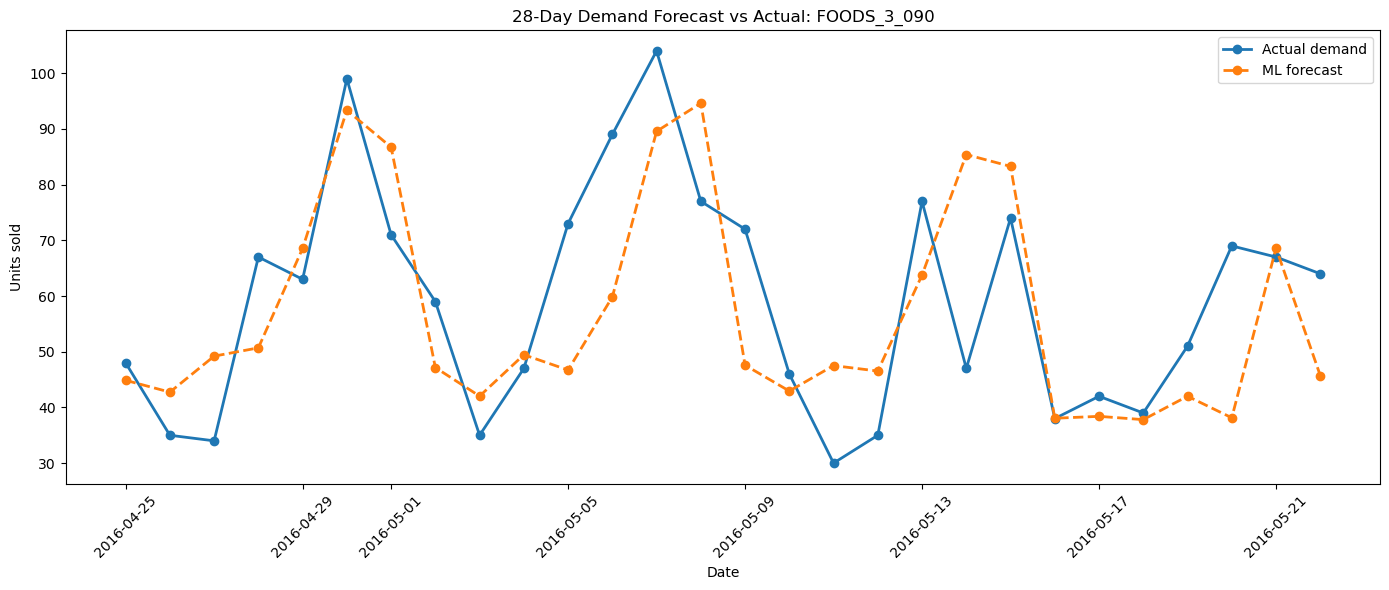

In [48]:
selected_sku = "FOODS_3_090"

chart_data = ml_results[
    ml_results["item_id"] == selected_sku
].copy()

plt.figure(figsize=(14, 6))

plt.plot(
    chart_data["date"],
    chart_data["actual_units_sold"],
    label="Actual demand",
    marker="o",
    linewidth=2
)

plt.plot(
    chart_data["date"],
    chart_data["ml_prediction"],
    label="ML forecast",
    marker="o",
    linestyle="--",
    linewidth=2
)

plt.title(f"28-Day Demand Forecast vs Actual: {selected_sku}")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "forecast_vs_actual_foods_3_090.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Planning assumptions: clearly documented and adjustable
LEAD_TIME_DAYS = 7
SERVICE_LEVEL_Z = 1.645
FORECAST_HORIZON_DAYS = 28

# SKU-level forecast error
sku_error = (
    ml_results
    .groupby("item_id", as_index=False)
    .agg(
        predicted_28_day_demand=("ml_prediction", "sum"),
        actual_28_day_demand=("actual_units_sold", "sum"),
        forecast_rmse=(
            "actual_units_sold",
            lambda actual: np.sqrt(
                np.mean(
                    (
                        actual -
                        ml_results.loc[
                            actual.index,
                            "ml_prediction"
                        ]
                    ) ** 2
                )
            )
        )
    )
)

# Inventory policy calculation
inventory_recommendations = sku_error.copy()

inventory_recommendations["forecast_daily_demand"] = (
    inventory_recommendations["predicted_28_day_demand"] /
    FORECAST_HORIZON_DAYS
)

# Safety stock based on forecast uncertainty during the 7-day lead time
inventory_recommendations["safety_stock_units"] = np.ceil(
    SERVICE_LEVEL_Z *
    inventory_recommendations["forecast_rmse"] *
    np.sqrt(LEAD_TIME_DAYS)
)

# Inventory position that triggers a new replenishment order
inventory_recommendations["reorder_point_units"] = np.ceil(
    (
        inventory_recommendations["forecast_daily_demand"] *
        LEAD_TIME_DAYS
    )
    +
    inventory_recommendations["safety_stock_units"]
)

# Stock required to cover the next 28 days plus safety stock
inventory_recommendations["recommended_28_day_stock_units"] = np.ceil(
    inventory_recommendations["predicted_28_day_demand"]
    +
    inventory_recommendations["safety_stock_units"]
)

inventory_recommendations = (
    inventory_recommendations
    .merge(
        forecasting_scope[
            ["item_id", "dept_id", "cat_id", "total_revenue"]
        ],
        on="item_id",
        how="left"
    )
    .sort_values("recommended_28_day_stock_units", ascending=False)
)

# Round presentation columns
inventory_recommendations["forecast_daily_demand"] = (
    inventory_recommendations["forecast_daily_demand"].round(2)
)

inventory_recommendations["forecast_rmse"] = (
    inventory_recommendations["forecast_rmse"].round(2)
)

display(
    inventory_recommendations[
        [
            "item_id",
            "cat_id",
            "total_revenue",
            "forecast_daily_demand",
            "forecast_rmse",
            "safety_stock_units",
            "reorder_point_units",
            "recommended_28_day_stock_units"
        ]
    ]
)

inventory_recommendations.to_csv(
    OUTPUT_DIR / "inventory_replenishment_recommendations.csv",
    index=False
)

,item_id,cat_id,total_revenue,forecast_daily_demand,forecast_rmse,safety_stock_units,reorder_point_units,recommended_28_day_stock_units
6,FOODS_3_090,FOODS,175257.74,56.83,16.14,71.0,469.0,1663.0
14,FOODS_3_586,FOODS,141530.58,44.25,7.73,34.0,344.0,1273.0
9,FOODS_3_252,FOODS,115746.30,39.14,10.43,46.0,320.0,1142.0
15,FOODS_3_587,FOODS,132607.48,27.40,10.66,47.0,239.0,815.0
16,FOODS_3_714,FOODS,82933.86,23.62,7.86,35.0,201.0,697.0
13,FOODS_3_555,FOODS,61281.68,18.75,4.29,19.0,151.0,545.0
5,FOODS_3_080,FOODS,62934.34,18.62,5.03,22.0,153.0,544.0
1,FOODS_2_197,FOODS,133059.54,17.80,8.20,36.0,161.0,535.0
7,FOODS_3_099,FOODS,83910.46,16.53,6.22,28.0,144.0,491.0
0,FOODS_2_019,FOODS,114867.28,14.49,4.99,22.0,124.0,428.0


## Inventory-Replenishment Policy

The model generates a 28-day demand forecast for the 20 highest-value, smooth-demand SKUs. Reorder points use a seven-day supplier lead-time assumption and a 95% target service level.

Safety stock is calculated from SKU-level forecast RMSE, allowing higher inventory buffers for uncertain demand and leaner inventory for products with more reliable forecasts. The lead time and service-level assumptions are configurable inputs in the inventory policy.

In [50]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    forecast_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(feature_importance)

,feature,importance_mean,importance_std
1,sell_price,2.873518,0.202951
7,item_id,2.752954,0.204051
0,lag_28,1.544912,0.126016
4,day_of_week,0.965058,0.131990
6,snap_CA,0.080610,0.038869
3,week_of_year,0.058209,0.063871
9,event_name_1,0.042448,0.024346
2,month,0.020389,0.007442
8,cat_id,0.004129,0.008821
5,is_weekend,0.000000,0.000000


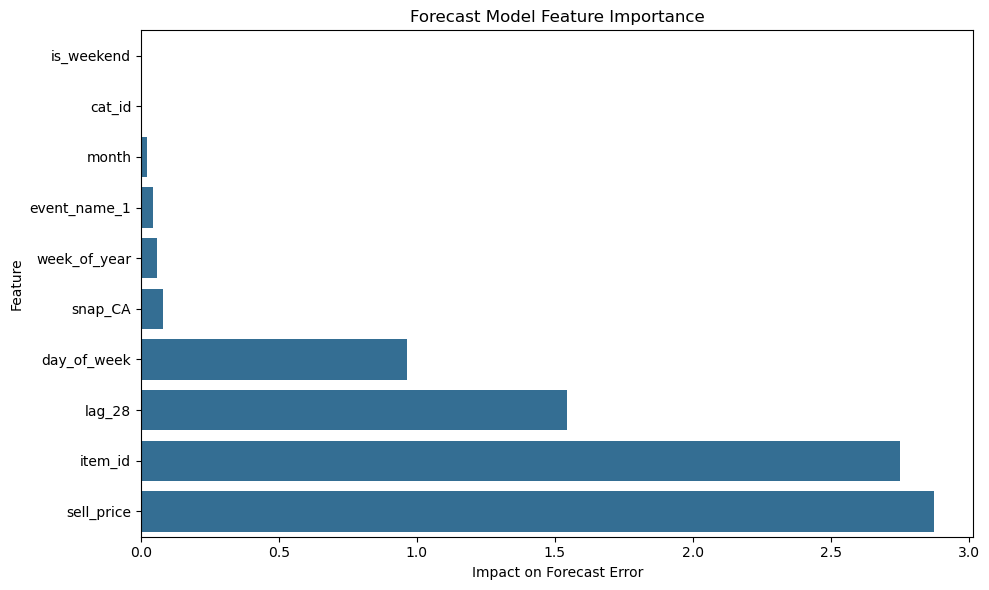

In [51]:
plot_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_importance,
    x="importance_mean",
    y="feature",
    color="#2471A3"
)

plt.title("Forecast Model Feature Importance")
plt.xlabel("Impact on Forecast Error")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "forecast_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

feature_importance.to_csv(
    OUTPUT_DIR / "forecast_feature_importance.csv",
    index=False
)

In [52]:
import joblib

joblib.dump(
    forecast_model,
    PROJECT_ROOT / "src" / "m5_demand_forecast_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


## Model Explainability

Permutation importance shows that selling price is the strongest forecasting driver, followed by SKU-level demand behavior and 28-day historical demand. This indicates that pricing strategy, product-level seasonality, and weekly shopping patterns should be incorporated into replenishment planning.

Event indicators and weekend status had limited impact for this selected group of A-class, smooth-demand SKUs.

In [53]:
model_comparison = pd.DataFrame({
    "model": ["Seasonal Naïve Baseline", "ML Forecast Model"],
    "mae_units": [mae_baseline, mae_ml],
    "rmse_units": [rmse_baseline, rmse_ml],
    "wape_percent": [wape_baseline, wape_ml],
    "forecast_bias_percent": [bias_baseline, bias_ml]
})

model_comparison["wape_percent"] = (
    model_comparison["wape_percent"].round(2)
)

model_comparison["forecast_bias_percent"] = (
    model_comparison["forecast_bias_percent"].round(2)
)

display(model_comparison)

model_comparison.to_csv(
    OUTPUT_DIR / "model_comparison_metrics.csv",
    index=False
)

,model,mae_units,rmse_units,wape_percent,forecast_bias_percent
0,Seasonal Naïve Baseline,6.026786,8.793362,34.29,-2.55
1,ML Forecast Model,4.689656,6.852164,26.68,2.16


/var/folders/wc/lx3pfn8x11z402lzlm429n0w0000gn/T/ipykernel_90819/1227975571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


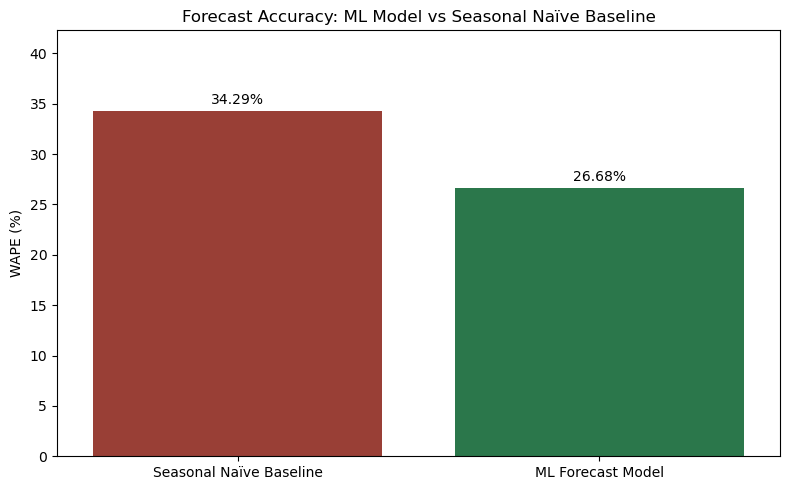

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="model",
    y="wape_percent",
    palette=["#A93226", "#1E8449"]
)

plt.title("Forecast Accuracy: ML Model vs Seasonal Naïve Baseline")
plt.xlabel("")
plt.ylabel("WAPE (%)")

for index, value in enumerate(model_comparison["wape_percent"]):
    plt.text(index, value + 0.7, f"{value:.2f}%", ha="center")

plt.ylim(0, max(model_comparison["wape_percent"]) + 8)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ml_vs_baseline_wape.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Use richer demand-history features safely through recursive forecasting
recursive_numeric_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_28",
    "sell_price",
    "month",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "snap_CA"
]

recursive_categorical_features = [
    "item_id",
    "cat_id",
    "event_name_1"
]

recursive_feature_columns = (
    recursive_numeric_features +
    recursive_categorical_features
)

X_train_recursive = train_data[recursive_feature_columns].copy()
y_train_recursive = train_data["units_sold"].copy()

recursive_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            recursive_categorical_features
        )
    ],
    remainder="passthrough"
)

lightgbm_recursive_model = Pipeline(steps=[
    ("preprocessor", recursive_preprocessor),
    (
        "model",
        LGBMRegressor(
            objective="regression_l1",
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

lightgbm_recursive_model.fit(
    X_train_recursive,
    y_train_recursive
)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


In [57]:
# Create historical demand arrays using only the training period
demand_history = (
    train_data
    .sort_values(["item_id", "date"])
    .groupby("item_id")["units_sold"]
    .apply(list)
    .to_dict()
)

recursive_predictions = []

# Forecast one calendar day at a time.
# Predictions become part of demand history for later forecast days.
for forecast_date in sorted(test_data["date"].unique()):

    daily_rows = (
        test_data[test_data["date"] == forecast_date]
        .sort_values("item_id")
    )

    daily_feature_rows = []
    daily_metadata = []

    for _, row in daily_rows.iterrows():
        sku = row["item_id"]
        history = demand_history[sku]

        feature_row = row[recursive_feature_columns].to_dict()

        # Rebuild demand-history features using historical actuals
        # and previous model predictions only.
        feature_row["lag_1"] = history[-1]
        feature_row["lag_7"] = history[-7]
        feature_row["lag_14"] = history[-14]
        feature_row["lag_28"] = history[-28]

        feature_row["rolling_mean_7"] = np.mean(history[-7:])
        feature_row["rolling_mean_14"] = np.mean(history[-14:])
        feature_row["rolling_mean_28"] = np.mean(history[-28:])
        feature_row["rolling_std_28"] = np.std(history[-28:], ddof=1)

        daily_feature_rows.append(feature_row)

        daily_metadata.append({
            "date": forecast_date,
            "item_id": sku,
            "actual_units_sold": row["units_sold"]
        })

    # Predict all 20 SKUs for the selected date
    daily_features = pd.DataFrame(daily_feature_rows)
    daily_predictions = lightgbm_recursive_model.predict(daily_features)

    # Store predictions and append them to history for future days
    for metadata, prediction in zip(daily_metadata, daily_predictions):
        predicted_demand = max(0, float(prediction))

        recursive_predictions.append({
            "date": metadata["date"],
            "item_id": metadata["item_id"],
            "actual_units_sold": metadata["actual_units_sold"],
            "lightgbm_recursive_prediction": predicted_demand
        })

        demand_history[metadata["item_id"]].append(predicted_demand)

lightgbm_recursive_results = pd.DataFrame(recursive_predictions)

print("Recursive predictions created:", lightgbm_recursive_results.shape)
display(lightgbm_recursive_results.head())

Recursive predictions created: (560, 4)


,date,item_id,actual_units_sold,lightgbm_recursive_prediction
0,2016-04-25,FOODS_2_019,8,13.924842
1,2016-04-25,FOODS_2_197,17,17.567700
2,2016-04-25,FOODS_2_244,7,5.613359
3,2016-04-25,FOODS_2_276,12,9.716469
4,2016-04-25,FOODS_2_347,13,9.241599


In [58]:
mae_lightgbm = mean_absolute_error(
    lightgbm_recursive_results["actual_units_sold"],
    lightgbm_recursive_results["lightgbm_recursive_prediction"]
)

rmse_lightgbm = np.sqrt(
    mean_squared_error(
        lightgbm_recursive_results["actual_units_sold"],
        lightgbm_recursive_results["lightgbm_recursive_prediction"]
    )
)

wape_lightgbm = (
    (
        lightgbm_recursive_results["actual_units_sold"] -
        lightgbm_recursive_results["lightgbm_recursive_prediction"]
    )
    .abs()
    .sum()
    /
    lightgbm_recursive_results["actual_units_sold"].sum()
) * 100

bias_lightgbm = (
    (
        lightgbm_recursive_results["lightgbm_recursive_prediction"].sum()
        -
        lightgbm_recursive_results["actual_units_sold"].sum()
    )
    /
    lightgbm_recursive_results["actual_units_sold"].sum()
) * 100

improvement_vs_baseline = (
    (wape_baseline - wape_lightgbm) / wape_baseline
) * 100

improvement_vs_hist_model = (
    (wape_ml - wape_lightgbm) / wape_ml
) * 100

print("Recursive LightGBM Forecast Results")
print(f"MAE: {mae_lightgbm:.2f} units")
print(f"RMSE: {rmse_lightgbm:.2f} units")
print(f"WAPE: {wape_lightgbm:.2f}%")
print(f"Forecast Bias: {bias_lightgbm:.2f}%")
print(f"WAPE improvement vs baseline: {improvement_vs_baseline:.2f}%")
print(f"WAPE improvement vs prior ML model: {improvement_vs_hist_model:.2f}%")

Recursive LightGBM Forecast Results
MAE: 4.43 units
RMSE: 6.56 units
WAPE: 25.21%
Forecast Bias: -6.22%
WAPE improvement vs baseline: 26.49%
WAPE improvement vs prior ML model: 5.53%


In [59]:
joblib.dump(
    lightgbm_recursive_model,
    PROJECT_ROOT / "src" / "lightgbm_recursive_demand_forecast_model.joblib"
)

lightgbm_recursive_results.to_csv(
    OUTPUT_DIR / "lightgbm_recursive_forecast_predictions.csv",
    index=False
)

final_model_metrics = pd.DataFrame({
    "model": [
        "Seasonal Naïve Baseline",
        "Initial ML Model",
        "Recursive LightGBM"
    ],
    "wape_percent": [
        wape_baseline,
        wape_ml,
        wape_lightgbm
    ],
    "wape_derived_accuracy_percent": [
        100 - wape_baseline,
        100 - wape_ml,
        100 - wape_lightgbm
    ],
    "forecast_bias_percent": [
        bias_baseline,
        bias_ml,
        bias_lightgbm
    ]
})

final_model_metrics = final_model_metrics.round(2)

display(final_model_metrics)

final_model_metrics.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False
)

,model,wape_percent,wape_derived_accuracy_percent,forecast_bias_percent
0,Seasonal Naïve Baseline,34.29,65.71,-2.55
1,Initial ML Model,26.68,73.32,2.16
2,Recursive LightGBM,25.21,74.79,-6.22


In [60]:
# Copy the final LightGBM forecast results
final_inventory_input = lightgbm_recursive_results.copy()

# Create error measures for SKU-specific safety stock
final_inventory_input["forecast_error"] = (
    final_inventory_input["actual_units_sold"] -
    final_inventory_input["lightgbm_recursive_prediction"]
)

final_inventory_input["squared_error"] = (
    final_inventory_input["forecast_error"] ** 2
)

# Apply a bias adjustment because LightGBM under-forecasted by 6.22%
BIAS_ADJUSTMENT_FACTOR = 1 - (bias_lightgbm / 100)

final_inventory_input["bias_adjusted_prediction"] = (
    final_inventory_input["lightgbm_recursive_prediction"] *
    BIAS_ADJUSTMENT_FACTOR
)

# Final SKU-level forecast and uncertainty
final_sku_inventory = (
    final_inventory_input
    .groupby("item_id", as_index=False)
    .agg(
        predicted_28_day_demand=(
            "lightgbm_recursive_prediction",
            "sum"
        ),
        bias_adjusted_28_day_demand=(
            "bias_adjusted_prediction",
            "sum"
        ),
        actual_28_day_demand=("actual_units_sold", "sum"),
        forecast_rmse=("squared_error", lambda x: np.sqrt(x.mean()))
    )
)

# Inventory assumptions
LEAD_TIME_DAYS = 7
SERVICE_LEVEL_Z = 1.645
FORECAST_HORIZON_DAYS = 28

final_sku_inventory["forecast_daily_demand"] = (
    final_sku_inventory["bias_adjusted_28_day_demand"] /
    FORECAST_HORIZON_DAYS
)

final_sku_inventory["safety_stock_units"] = np.ceil(
    SERVICE_LEVEL_Z *
    final_sku_inventory["forecast_rmse"] *
    np.sqrt(LEAD_TIME_DAYS)
)

final_sku_inventory["reorder_point_units"] = np.ceil(
    (
        final_sku_inventory["forecast_daily_demand"] *
        LEAD_TIME_DAYS
    )
    +
    final_sku_inventory["safety_stock_units"]
)

final_sku_inventory["recommended_28_day_stock_units"] = np.ceil(
    final_sku_inventory["bias_adjusted_28_day_demand"]
    +
    final_sku_inventory["safety_stock_units"]
)

# Add business context
final_inventory_recommendations = (
    final_sku_inventory
    .merge(
        forecasting_scope[
            ["item_id", "dept_id", "cat_id", "total_revenue"]
        ],
        on="item_id",
        how="left"
    )
    .sort_values("recommended_28_day_stock_units", ascending=False)
)

# Presentation formatting
for column in [
    "predicted_28_day_demand",
    "bias_adjusted_28_day_demand",
    "actual_28_day_demand",
    "forecast_daily_demand",
    "forecast_rmse"
]:
    final_inventory_recommendations[column] = (
        final_inventory_recommendations[column].round(2)
    )

display(
    final_inventory_recommendations[
        [
            "item_id",
            "cat_id",
            "total_revenue",
            "predicted_28_day_demand",
            "bias_adjusted_28_day_demand",
            "forecast_rmse",
            "safety_stock_units",
            "reorder_point_units",
            "recommended_28_day_stock_units"
        ]
    ]
)

final_inventory_recommendations.to_csv(
    OUTPUT_DIR / "final_lightgbm_inventory_recommendations.csv",
    index=False
)

,item_id,cat_id,total_revenue,predicted_28_day_demand,bias_adjusted_28_day_demand,forecast_rmse,safety_stock_units,reorder_point_units,recommended_28_day_stock_units
6,FOODS_3_090,FOODS,175257.74,1487.13,1579.69,15.37,67.0,462.0,1647.0
14,FOODS_3_586,FOODS,141530.58,1146.39,1217.75,6.92,31.0,336.0,1249.0
9,FOODS_3_252,FOODS,115746.30,1087.40,1155.08,9.40,41.0,330.0,1197.0
15,FOODS_3_587,FOODS,132607.48,569.87,605.34,9.64,42.0,194.0,648.0
16,FOODS_3_714,FOODS,82933.86,525.24,557.93,7.03,31.0,171.0,589.0
1,FOODS_2_197,FOODS,133059.54,496.75,527.66,8.53,38.0,170.0,566.0
13,FOODS_3_555,FOODS,61281.68,483.39,513.47,5.00,22.0,151.0,536.0
5,FOODS_3_080,FOODS,62934.34,475.80,505.42,5.64,25.0,152.0,531.0
0,FOODS_2_019,FOODS,114867.28,445.20,472.91,5.64,25.0,144.0,498.0
7,FOODS_3_099,FOODS,83910.46,433.43,460.40,5.90,26.0,142.0,487.0


In [61]:
# Executive KPI table for the dashboard
executive_kpis = pd.DataFrame({
    "kpi_name": [
        "Total Sales",
        "Total Profit",
        "Unique Orders",
        "Late Delivery Rate",
        "Average Actual Shipping Days",
        "Average Shipping Delay Days",
        "Forecast WAPE",
        "Forecast Accuracy",
        "Forecast Bias",
        "Forecasted A-Class SKUs"
    ],
    "kpi_value": [
        total_sales,
        total_profit,
        total_orders,
        late_delivery_rate,
        average_shipping_days,
        average_shipping_delay,
        wape_lightgbm,
        100 - wape_lightgbm,
        bias_lightgbm,
        forecast_data["item_id"].nunique()
    ],
    "unit": [
        "USD",
        "USD",
        "Orders",
        "Percent",
        "Days",
        "Days",
        "Percent",
        "Percent",
        "Percent",
        "SKUs"
    ]
})

executive_kpis["kpi_value"] = executive_kpis["kpi_value"].round(2)

display(executive_kpis)

,kpi_name,kpi_value,unit
0,Total Sales,33054402.38,USD
1,Total Profit,3966902.97,USD
2,Unique Orders,65752.00,Orders
3,Late Delivery Rate,54.83,Percent
4,Average Actual Shipping Days,3.50,Days
5,Average Shipping Delay Days,0.57,Days
6,Forecast WAPE,25.21,Percent
7,Forecast Accuracy,74.79,Percent
8,Forecast Bias,-6.22,Percent
9,Forecasted A-Class SKUs,20.00,SKUs


In [62]:
# DataCo delivery-risk module
shipping_mode_performance.to_csv(
    OUTPUT_DIR / "dashboard_shipping_mode_performance.csv",
    index=False
)

region_impact.to_csv(
    OUTPUT_DIR / "dashboard_regional_delivery_risk.csv",
    index=False
)

category_performance.to_csv(
    OUTPUT_DIR / "dashboard_category_performance.csv",
    index=False
)

# M5 forecast and inventory module
final_model_metrics.to_csv(
    OUTPUT_DIR / "dashboard_forecast_model_comparison.csv",
    index=False
)

final_inventory_recommendations.to_csv(
    OUTPUT_DIR / "dashboard_inventory_recommendations.csv",
    index=False
)

lightgbm_recursive_results.to_csv(
    OUTPUT_DIR / "dashboard_daily_forecast_predictions.csv",
    index=False
)

executive_kpis.to_csv(
    OUTPUT_DIR / "dashboard_executive_kpis.csv",
    index=False
)

print("Dashboard datasets exported successfully.")

Dashboard datasets exported successfully.
